In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib as mpl

survey='KVIOQ'
# survey='RYBERG-S1'
# survey='RYBERG-S2'
#survey='NMLSFJORD'

if survey == 'KVIOQ':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-'+survey+'/files/processed-log-data'
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-08-Kivioq.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-'+survey+'/files/processed-log-figures'
elif survey == 'RYBERG-S1':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-data'
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-02-00_00_2024-08-02-23_59_Sentinel-2_L2A_Highlight_Optimized_Natural_Color_RYBERGS1.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-figures'
elif survey == 'RYBERG-S2':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-data'    
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-02-00_00_2024-08-02-23_59_Sentinel-2_L2A_Highlight_Optimized_Natural_Color_RYBERGS2.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-RYBERG/files/processed-log-figures'
elif survey == 'NMLSFJORD':
    logdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-NMLSFJORD/files/processed-log-data'    
    geotiff_path = 'C:/Q-projects/Kang-Glac/Sentinel-images/2024-08-08-HarissonFjord.tiff'
    figdir='C:/gavia/controlcenter/db/SD041-KANG-GLAC-GEO-NMLSFJORD/files/processed-log-figures'
os.makedirs(figdir, exist_ok=True) 


df=pd.read_csv(os.path.join(logdir,'auvdata.csv'))
# convert lat/lon to decimal
latitude=df['Lat']
lat=latitude[latitude.notnull()]
DD=lat/100
DD=DD.astype('int')
SS=lat-DD*100
LatDec = DD + SS/60
latitude[latitude.notnull()]=LatDec
df['Lat']=latitude

longitude=df['Lon']
lon=longitude[longitude.notnull()]
DD=lon/100
DD=DD.astype('int')
SS=lon-DD*100
LonDec = DD + SS/60
longitude[longitude.notnull()]=LonDec
df['Lon']=longitude*-1

if survey == 'RYBERG-S2':
    df=df.loc[df['Lon'] >= -30.5]
elif survey == 'RYBERG-S1':
    df=df.loc[df['Lon'] <= -30.5]

C:\Users\Marphys\AppData\Local\Temp\ipykernel_16520\3044456294.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latitude[latitude.notnull()]=LatDec
C:\Users\Marphys\AppData\Local\Temp\ipykernel_16520\3044456294.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longitude[longitude.notnull()]=LonDec


C:\Users\Marphys\AppData\Local\Temp\ipykernel_16520\2964222624.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))


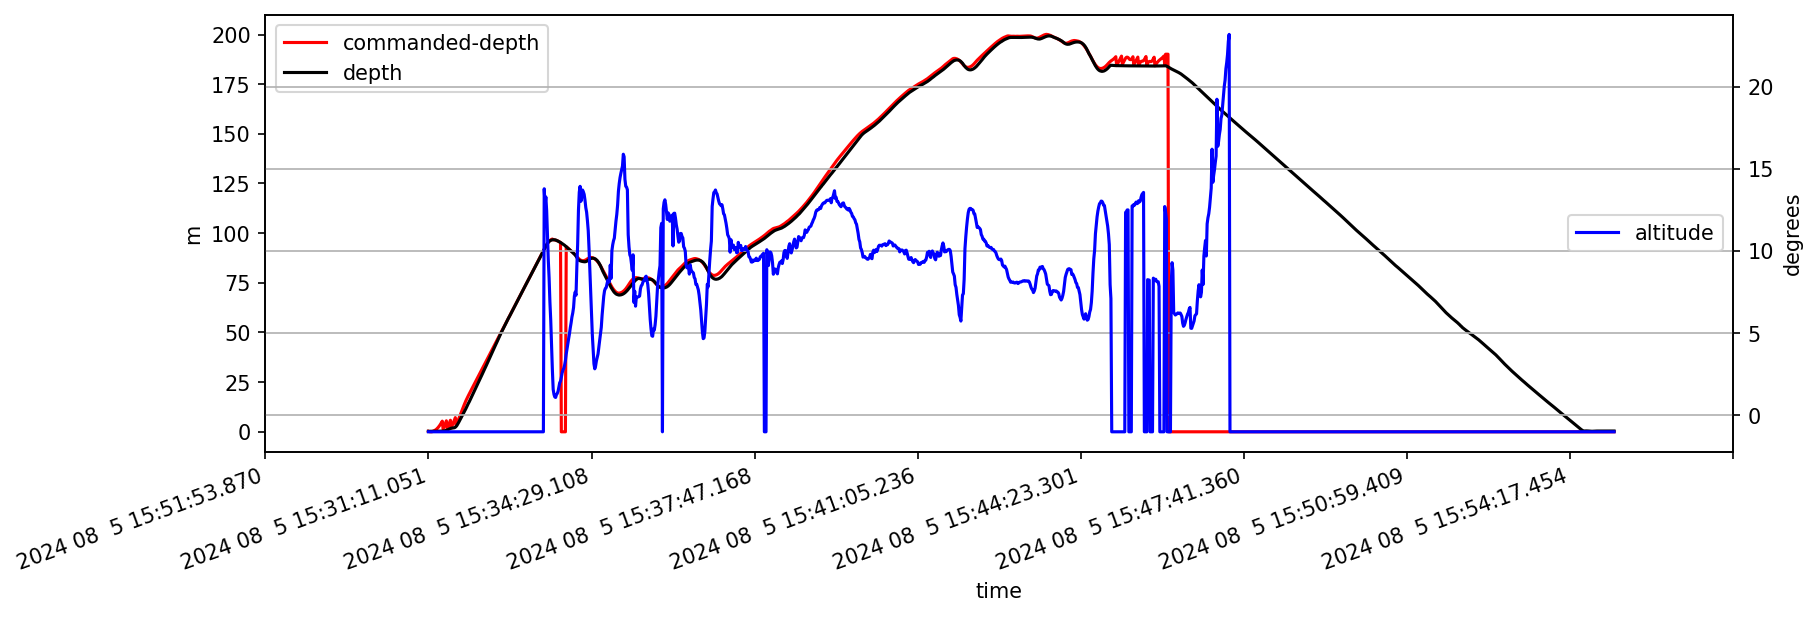

In [109]:
## depth vs. commandded depth
df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))
df=df.loc[(df['time'] >= '2024 08  5 15:31:10.951') & (df['time'] <= '2024 08  5 15:55:10.951')]

fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(12, 4), dpi=150)
df.plot(ax=ax,x='time',y=["commanded-depth","depth"],
                color=['red','black'],
                label=['commanded-depth',"depth"])
ax2 = ax.twinx()
df.plot(ax=ax2,x='time',
        y=["altitude"],
        color=['blue'],
        label=["altitude"])
plt.grid(True)
ax.set_ylabel('m')
ax2.set_ylabel('degrees')
ax.legend(loc=2)
ax2.legend(loc=5)
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=20, ha='right')

plt.savefig(os.path.join(figdir,survey+'_depth.png'),bbox_inches='tight', dpi=100)

plt.show()

C:\Users\Marphys\AppData\Local\Temp\ipykernel_16520\2016246776.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))


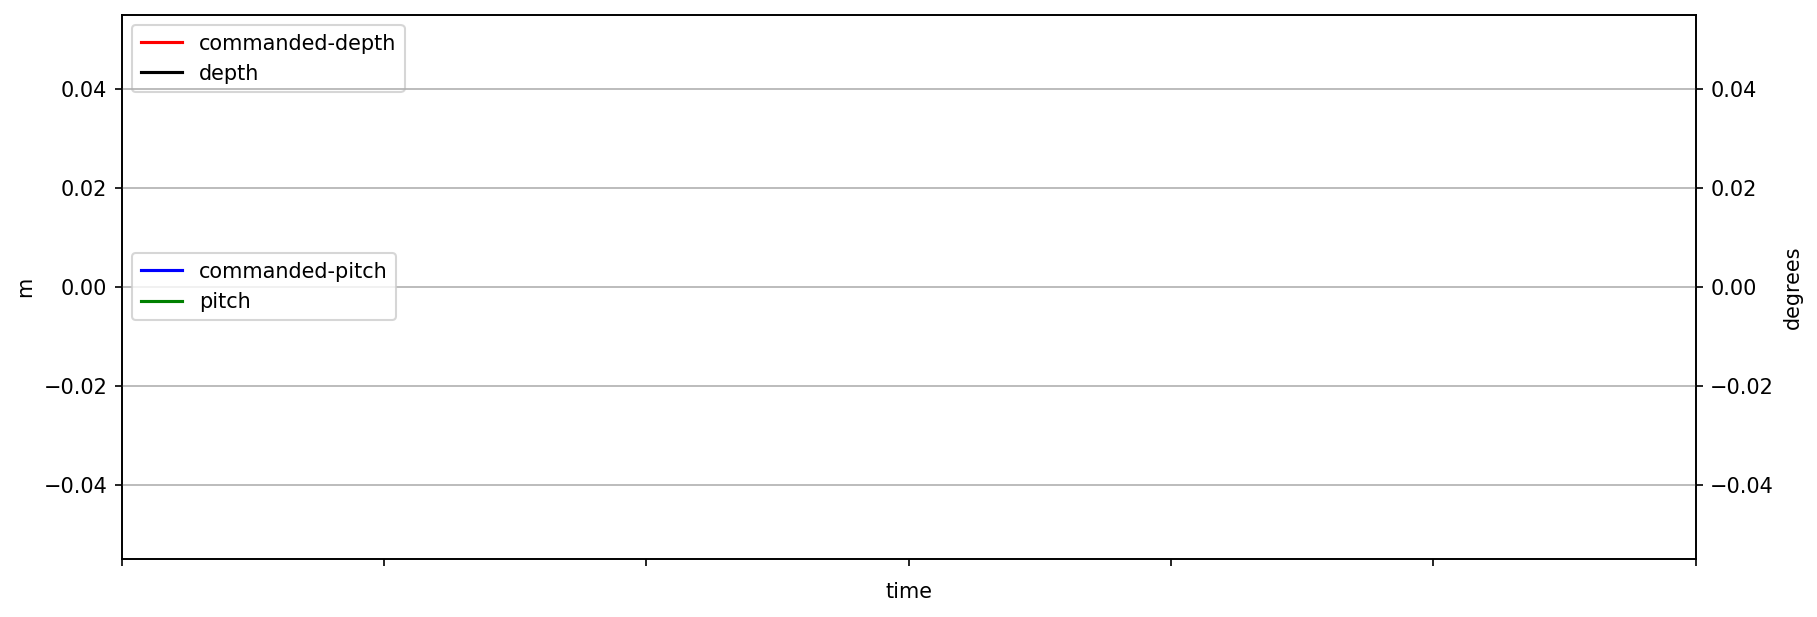

In [107]:
## depth vs. commandded depth
df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))
df=df.loc[(df['time'] >= '2024 08  7 17:39:17.575') & (df['time'] <= '2024 08  7 18:03:13.168')]

fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(12, 4), dpi=150)
df.plot(ax=ax,x='time',y=["commanded-depth","depth"],
                color=['red','black'],
                label=['commanded-depth',"depth"])
ax2 = ax.twinx()
df.plot(ax=ax2,x='time',
        y=["commanded-pitch","pitch"],
        color=['blue','green'],
        label=["commanded-pitch",'pitch'])
plt.grid(True)
ax.set_ylabel('m')
ax2.set_ylabel('degrees')
ax.legend(loc=2)
ax2.legend(loc=6)
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=20, ha='right')

plt.savefig(os.path.join(figdir,survey+'_depth.png'),bbox_inches='tight', dpi=100)

plt.show()

In [71]:
## depth vs. commandded depth
df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))
df=df.loc[(df['time'] >= '2024 08  7 17:39:17.575') & (df['time'] <= '2024 08  7 18:03:13.168')]

C:\Users\Marphys\AppData\Local\Temp\ipykernel_16520\1713634968.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))


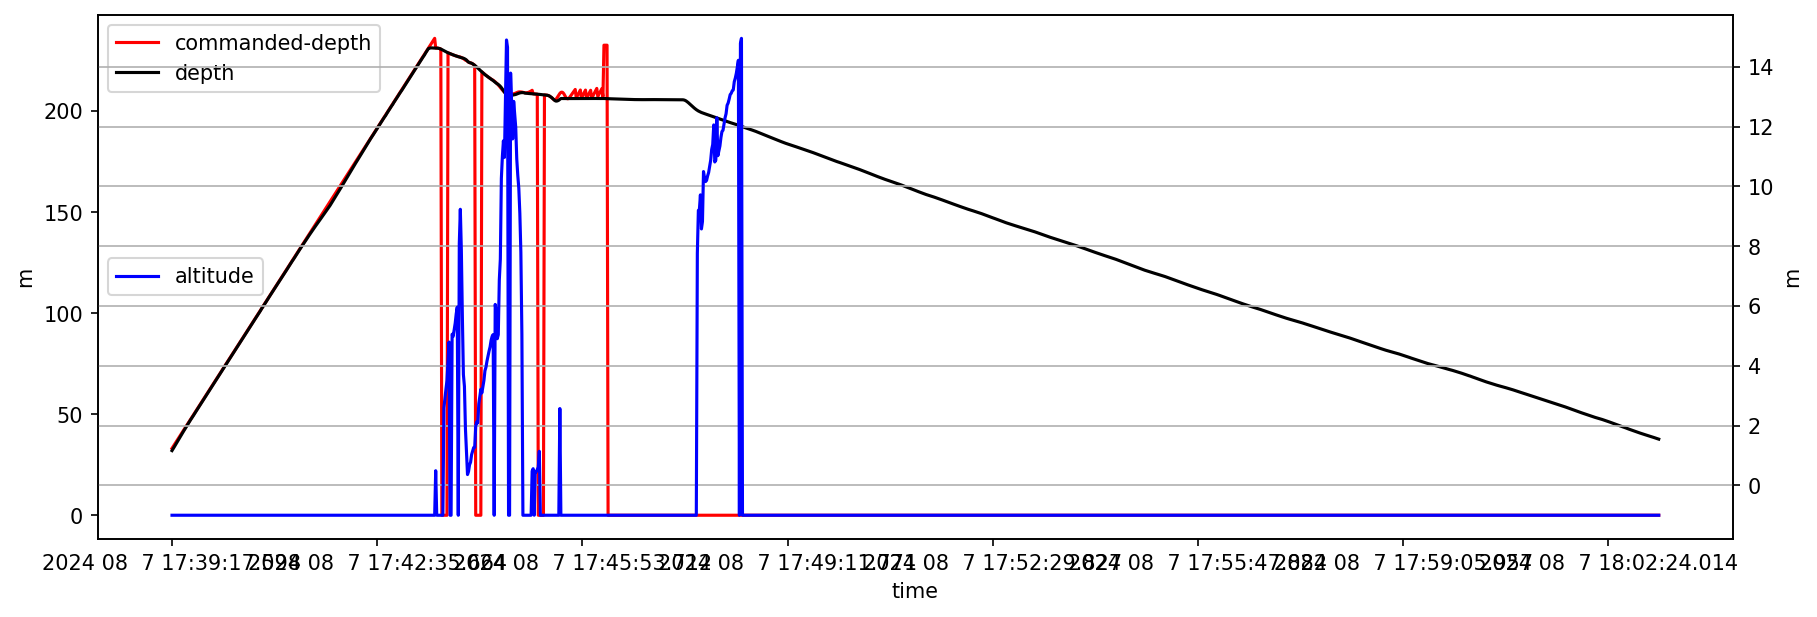

In [73]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(12, 4), dpi=150)
df.plot(ax=ax,x='time',y=["commanded-depth","depth"],
                color=['red','black'],
                label=['commanded-depth',"depth"])
ax2 = ax.twinx()
df.plot(ax=ax2,x='time',
        y=["altitude"],
        color=['blue'],
        label=["altitude"])
plt.grid(True)
ax.set_ylabel('m')
ax2.set_ylabel('m')
ax.legend(loc=2)
ax2.legend(loc=6)

plt.savefig(os.path.join(figdir,survey+'_altitude.png'),bbox_inches='tight', dpi=100)

plt.show()

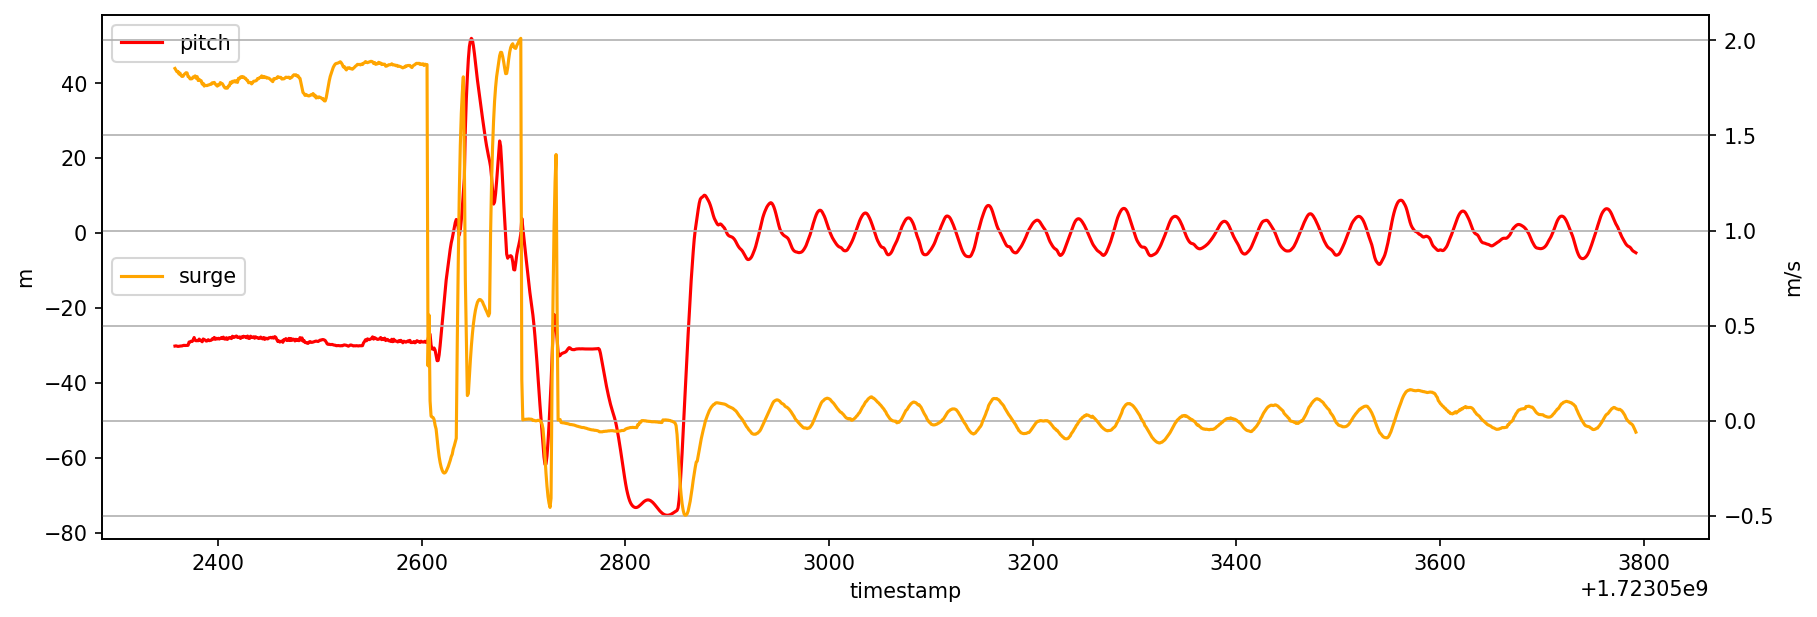

In [58]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(12, 4), dpi=150)
df.plot(ax=ax,x='timestamp',y=['pitch',],
                color=['red'],
                label=['pitch'])
ax2 = ax.twinx()
df.plot(ax=ax2,x='timestamp',
        y=["surge"],
        color=['orange'],
        label=['surge'])
plt.grid(True)
ax.set_ylabel('m')
ax2.set_ylabel('m/s')
ax.legend(loc=2)
ax2.legend(loc=6)

plt.savefig(os.path.join(figdir,survey+'_depth.png'),bbox_inches='tight', dpi=100)

plt.show()

C:\Users\Marphys\AppData\Local\Temp\ipykernel_16520\2209654441.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))


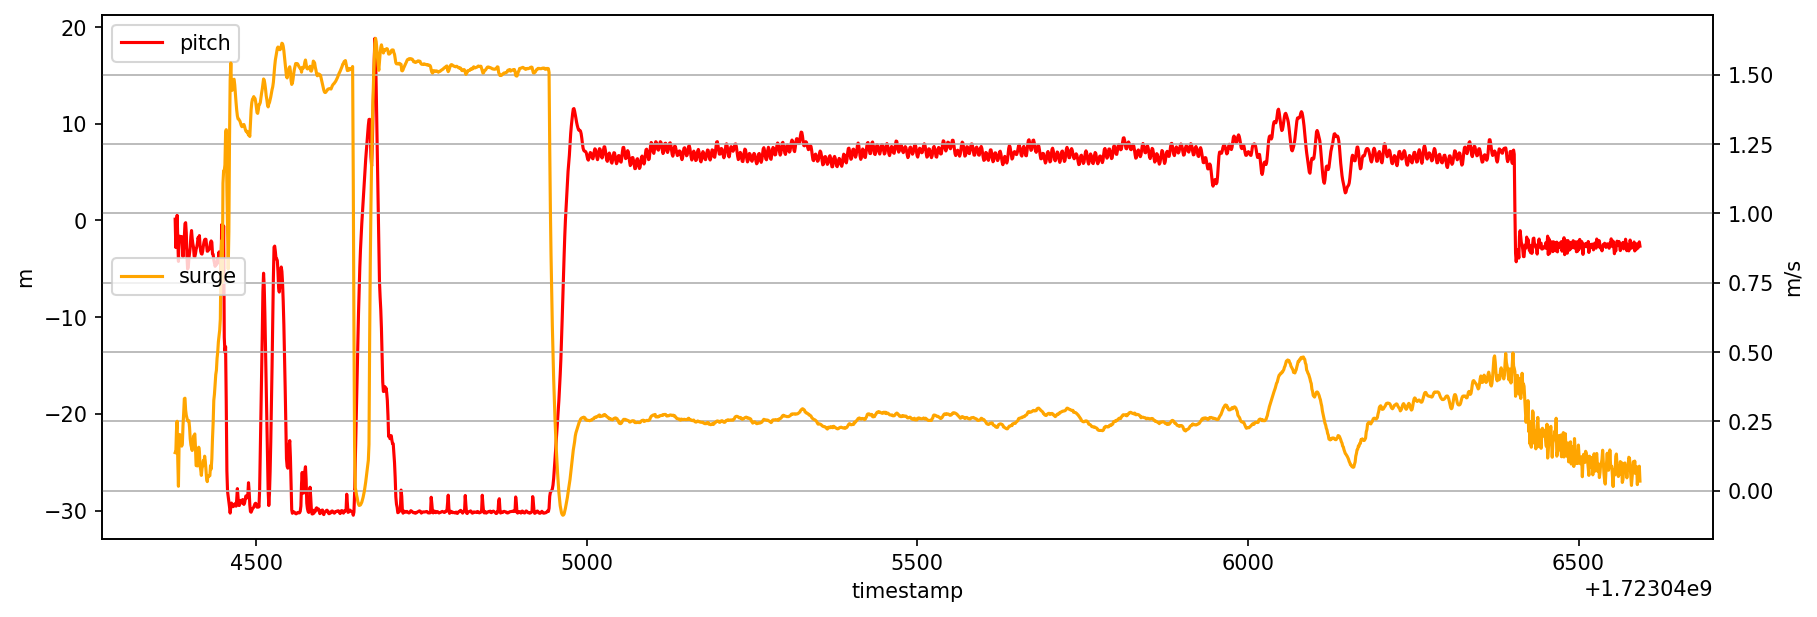

In [75]:
## depth vs. commandded depth
df=pd.read_csv(os.path.join(logdir,'autopilotdata.csv'))
df=df.loc[(df['time'] >= '2024 08  7 15:26:17.575') & (df['time'] <= '2024 08  7 16:03:13.168')]
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(12, 4), dpi=150)
df.plot(ax=ax,x='timestamp',y=['pitch',],
                color=['red'],
                label=['pitch'])
ax2 = ax.twinx()
df.plot(ax=ax2,x='timestamp',
        y=["surge"],
        color=['orange'],
        label=['surge'])
plt.grid(True)
ax.set_ylabel('m')
ax2.set_ylabel('m/s')
ax.legend(loc=2)
ax2.legend(loc=6)

plt.savefig(os.path.join(figdir,survey+'_depth.png'),bbox_inches='tight', dpi=100)

plt.show()

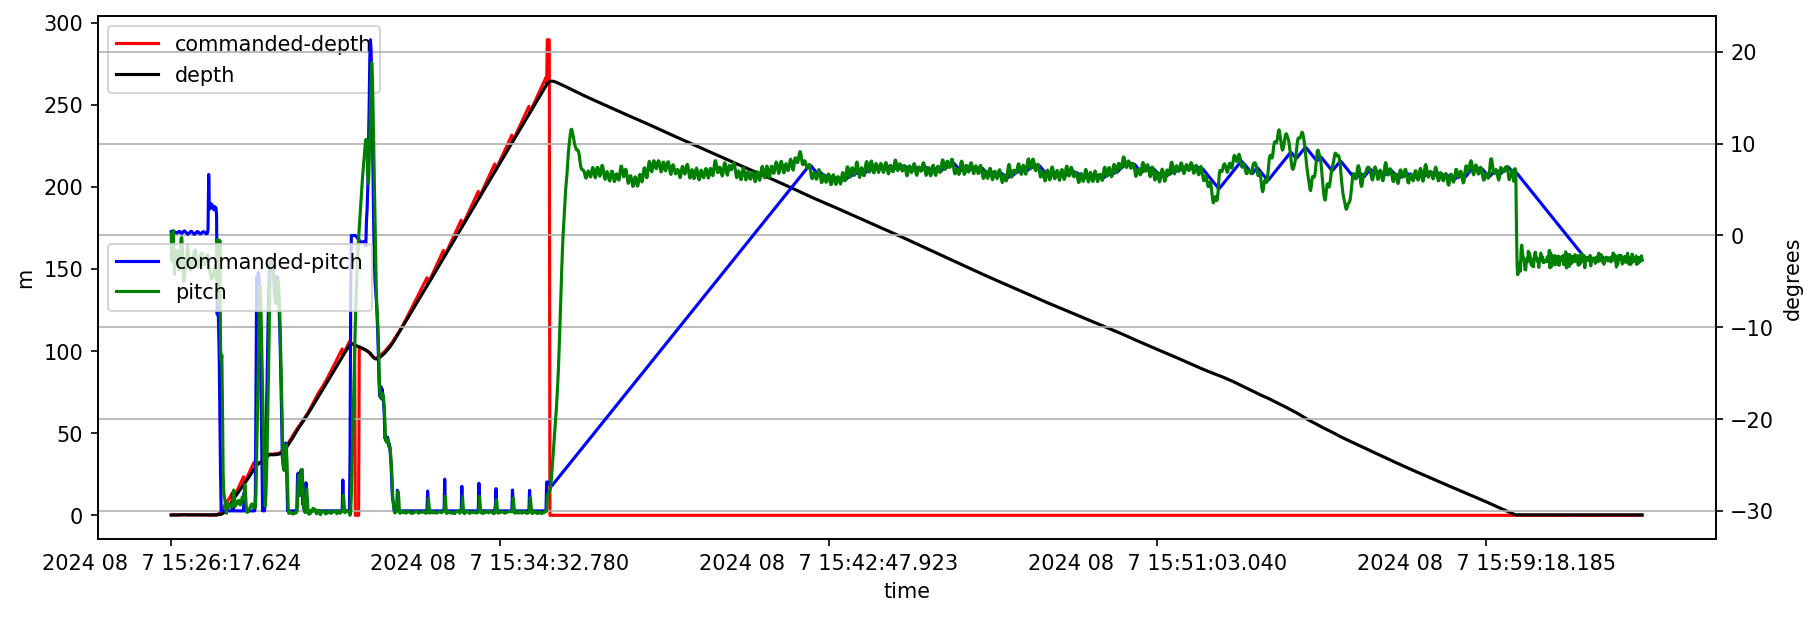

In [76]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(12, 4), dpi=150)
df.plot(ax=ax,x='time',y=["commanded-depth","depth"],
                color=['red','black'],
                label=['commanded-depth',"depth"])
ax2 = ax.twinx()
df.plot(ax=ax2,x='time',
        y=["commanded-pitch","pitch"],
        color=['blue','green'],
        label=["commanded-pitch",'pitch'])
plt.grid(True)
ax.set_ylabel('m')
ax2.set_ylabel('degrees')
ax.legend(loc=2)
ax2.legend(loc=6)

plt.savefig(os.path.join(figdir,survey+'_depth.png'),bbox_inches='tight', dpi=100)

plt.show()

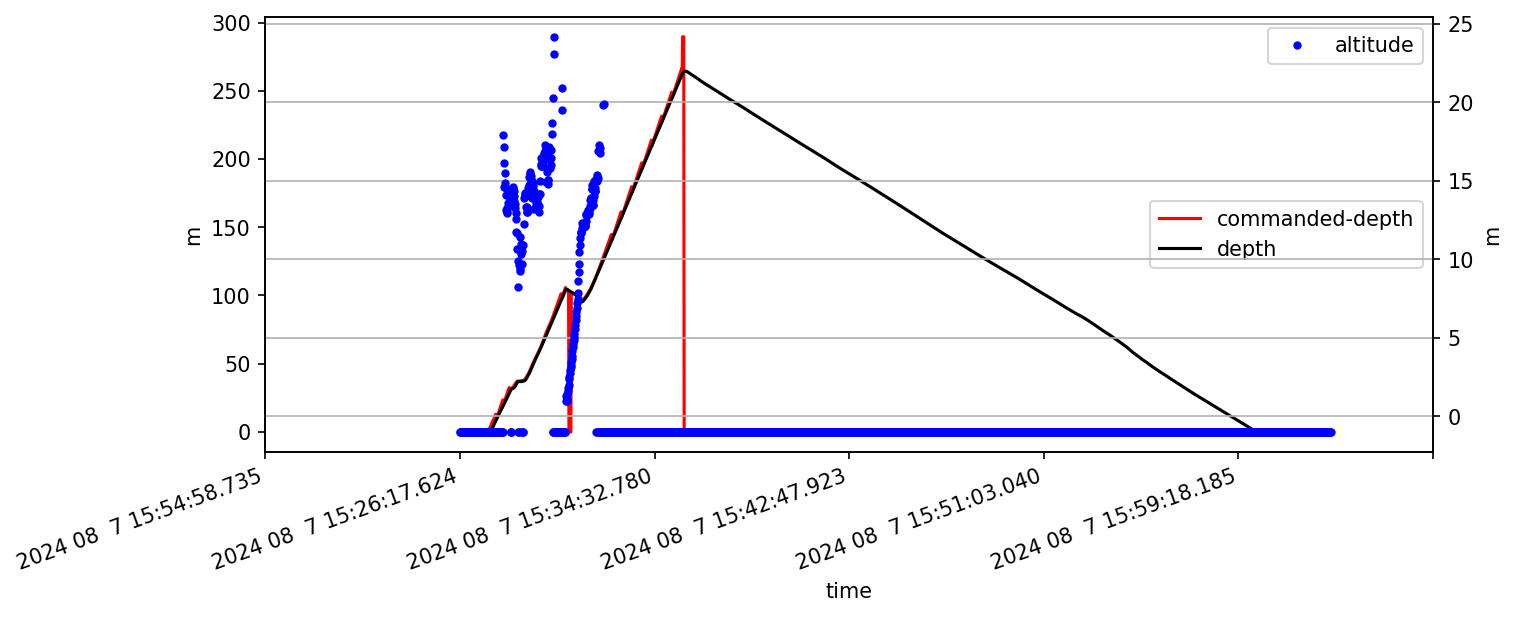

In [89]:
fig, ax = plt.subplots(1,1,constrained_layout=True,figsize=(10, 4), dpi=150)
df.plot(ax=ax,x='time',y=["commanded-depth","depth"],
                color=['red','black'],
                label=['commanded-depth',"depth"])
ax2 = ax.twinx()
df.plot(ax=ax2,x='time',
        y=["altitude"],
        marker = '.',
        linestyle='None',
        color=['blue'],
        label=["altitude"])
plt.grid(True)
ax.set_ylabel('m')
ax2.set_ylabel('m')
ax.legend(loc=5)
ax2.legend(loc=0)
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=20, ha='right')

plt.savefig(os.path.join(figdir,survey+'_altitude.png'),bbox_inches='tight', dpi=100)

plt.show()

In [90]:
df

,Unnamed: 0,timestamp,time,build-number,build-tag,motor-lowpower,max-allowed-depth,crush-depth,minimum-surface-pitch,minimum-surface-clearance,...,commanded-plane1,commanded-plane2,commanded-plane3,commanded-plane4,pitchrate,rollrate,yawrate,accelx,accely,accelz
18411,18411,1.723044e+09,2024 08 7 15:26:17.624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.9,-20.0,-13.0,-20.00,-2.161180,-0.237800,0.468606,-0.073242,0.137695,9.59668
18412,18412,1.723044e+09,2024 08 7 15:26:18.614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-4.5,-20.0,-20.0,-20.00,-1.769510,13.002100,0.335717,-0.420898,-0.575195,9.94531
18413,18413,1.723044e+09,2024 08 7 15:26:19.608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.1,-20.0,4.5,-20.00,3.315210,-5.567310,0.741376,-0.420898,-0.402344,9.82617
18414,18414,1.723044e+09,2024 08 7 15:26:20.598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.5,-20.0,20.0,0.72,1.258940,-20.268900,0.209823,0.266602,-0.455078,10.00000
18415,18415,1.723044e+09,2024 08 7 15:26:21.590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-5.6,-20.0,-20.0,-20.00,-2.986490,17.359400,-0.664441,-0.680664,-0.530273,9.87988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20644,20644,1.723047e+09,2024 08 7 16:03:08.928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.00,-0.895247,2.042280,-0.391670,-0.481445,-0.580078,9.72461
20645,20645,1.723047e+09,2024 08 7 16:03:09.919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.00,0.636464,-0.468606,-0.419647,-0.446289,-0.449219,9.74805
20646,20646,1.723047e+09,2024 08 7 16:03:10.909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.00,-0.657447,-1.692580,-0.020982,-0.435547,-0.700195,9.74121
20647,20647,1.723047e+09,2024 08 7 16:03:11.900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.00,1.587660,1.531710,0.447623,-0.439453,-1.052730,9.81738


<Axes: >

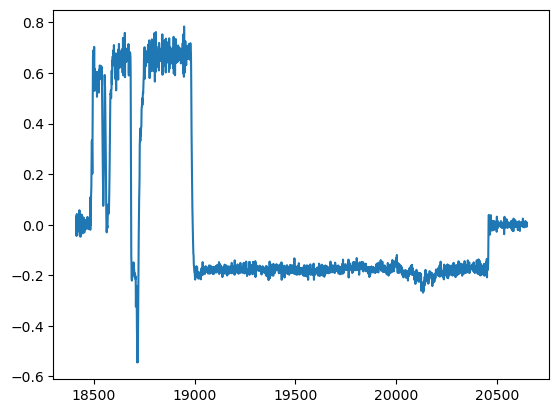

In [93]:
df.depth.diff().plot()